# analyzing fluorescence response re sound intensity with exclusive thresholds

In [1]:
# create dataframe including metadata

import lib.fileIngest as fileIngest
import joblib

dPaths = [r"C:\Manoj Data\TL_B10_Mouse04\AA0001"]
# df = fileIngest.qcamPath2table(dPaths)
df = fileIngest.qcamPath2table(dPaths, subfolder=True)
# joblib.dump(df,'../data/cache/TLB10_2_df_.joblib')
# df = joblib.load('../data/cache/TLB10_2_df_.joblib')
df

,qcam,dir,xsg,pulse,dB
0,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
1,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
2,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
3,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
4,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,16p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
...,...,...,...,...,...
134,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_60dB_10000msTotal_Fs250kHz,60.0
135,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_45dB_10000msTotal_Fs250kHz,45.0
136,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0
137,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0


In [2]:
# show files that will be excluded
df[df['dB'].isna()]

,qcam,dir,xsg,pulse,dB
0,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
1,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
2,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
3,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
4,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,16p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
5,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,16p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN
68,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,12p0kHzFreq_400msDur_3000msDel_10msRamp_3400ms...,NaN


In [3]:
# exclude unmatched stim data
df = df.dropna()
df

,qcam,dir,xsg,pulse,dB
6,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0
7,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,6-64kHz_60dB_10000msTotal_Fs250kHz,60.0
8,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0
10,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_30dB_10000msTotal_Fs250kHz,30.0
11,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_35dB_10000msTotal_Fs250kHz,35.0
...,...,...,...,...,...
134,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_60dB_10000msTotal_Fs250kHz,60.0
135,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_45dB_10000msTotal_Fs250kHz,45.0
136,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0
137,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0


In [4]:
# label injection conditions
import lib.metadataProcess as metadataProcess

df = df.copy()
df['treatment'] = metadataProcess.getInjectionCond(df)
df

# view pre- and post-ZX1 trace numbers
# df.groupby('treatment', sort=False)['qcam'].nunique()

,qcam,dir,xsg,pulse,dB,treatment
6,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0,preZX1
7,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,6-64kHz_60dB_10000msTotal_Fs250kHz,60.0,preZX1
8,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AAAA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,preZX1
10,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_30dB_10000msTotal_Fs250kHz,30.0,postZX1
11,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_35dB_10000msTotal_Fs250kHz,35.0,postZX1
...,...,...,...,...,...,...
134,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_60dB_10000msTotal_Fs250kHz,60.0,preZX1
135,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_45dB_10000msTotal_Fs250kHz,45.0,preZX1
136,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,preZX1
137,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0,preZX1


In [5]:
# get image data
import pandas as pd

# df, qcam2img, qcam2header = fileIngest.loadQCamTable(df)
# df

# remove first few pre-exposing traces according to time gaps between adjacent trials (threshold: 30 sec)
df_drop, qcam2img, qcam2header = fileIngest.loadQCamTable(df, preExpose_excl=True, loopGap=30)
df_drop

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX
0,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_30dB_10000msTotal_Fs250kHz,30.0,preZX1,200,2023-10-11 16:11:23,"(130, 174)"
1,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_35dB_10000msTotal_Fs250kHz,35.0,preZX1,200,2023-10-11 16:11:46,"(130, 174)"
2,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,preZX1,200,2023-10-11 16:12:06,"(130, 174)"
3,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_75dB_10000msTotal_Fs250kHz,75.0,preZX1,200,2023-10-11 16:12:26,"(130, 174)"
4,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_40dB_10000msTotal_Fs250kHz,40.0,preZX1,200,2023-10-11 16:12:46,"(130, 174)"
...,...,...,...,...,...,...,...,...,...
123,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_75dB_10000msTotal_Fs250kHz,75.0,postZX1,200,2023-10-11 18:04:17,"(130, 174)"
124,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,postZX1,200,2023-10-11 18:04:37,"(130, 174)"
125,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_55dB_10000msTotal_Fs250kHz,55.0,postZX1,200,2023-10-11 18:04:57,"(130, 174)"
126,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_80dB_10000msTotal_Fs250kHz,80.0,postZX1,200,2023-10-11 18:05:17,"(130, 174)"


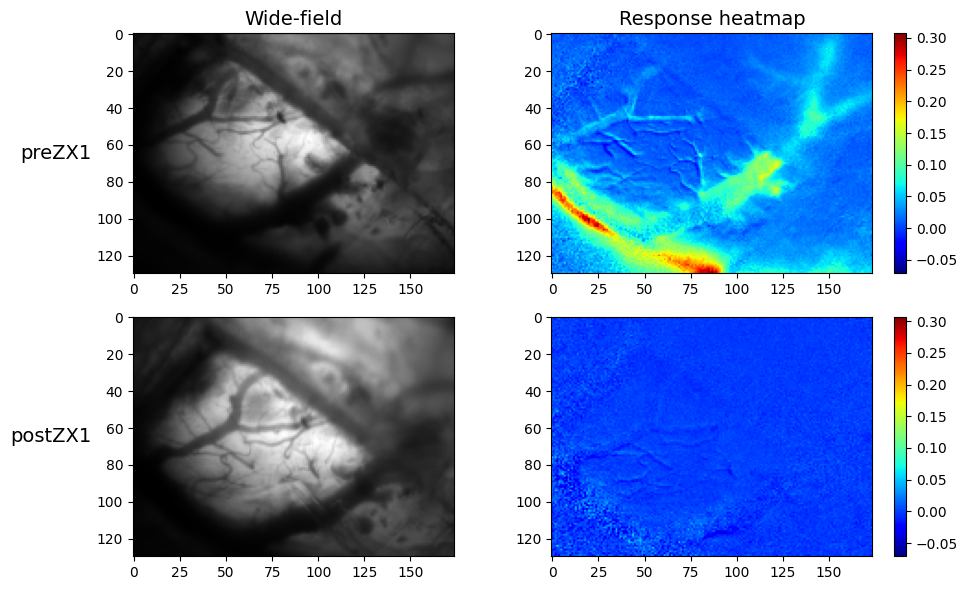

In [ ]:
# view wide-field image and response heatmap

# specify sound intensity, baseline and response time window
dB_plot = 80
t_base = (2.0, 3.0)
t_resp = (3.3, 4.0)

import lib.plotting as plotting
plotting.plot_respHeatmap(df_drop, dB_plot=dB_plot, t_baseline=t_base, t_temporalAvg=t_resp)

# show heatmaps with different color scaling
# plotting.plot_respHeatmap(df_drop, dB_plot=dB_plot, t_baseline=t_base, t_temporalAvg=t_resp, same_scale=False)

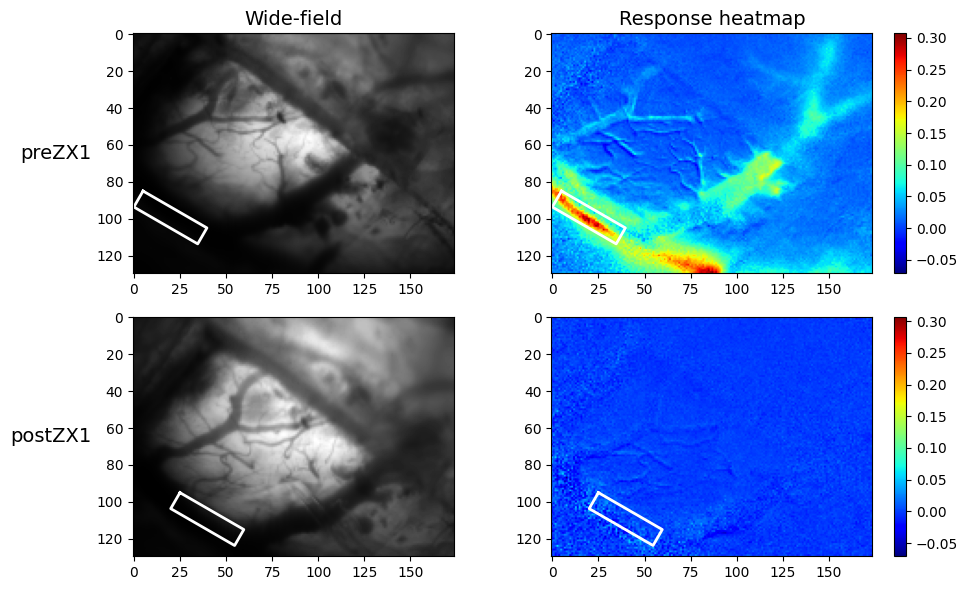

In [50]:
# # select ROI
# input ROI vertex coordinates to create a square mask

import lib.imgProcess as imgProcess

# if pre- and post-ZX1 use the same ROI
# set ROI coordinates and show ROI against wide-field image and response heatmap

# dmask = imgProcess.getSquareMask(5, 85, 40, 10, angle=90, rotate=30)
# plotting.plot_respHeatmap(df_drop, dB_plot=dB_plot, t_baseline=t_base, t_temporalAvg=t_resp, ROIcontour=dmask['ROIcontour'])

# save mask in the same folder as a `joblib`` file
# specify filename to be saved

# saveName = "response_mask"

# import os
# savePath = os.path.join(df_drop['dir'].iloc[0], f"{saveName}.joblib")
# if os.path.exists(savePath):
#     raise FileExistsError(f"File '{savePath}' already exists. Choose a different filename or delete the existing file.")
# joblib.dump(dmask['mask'], savePath)
# print(f"Mask saved successfully to: {savePath}")



# # if pre- and post-ZX1 use different ROIs (eg. platform moves to insert pipette)
# set ROI coordinates respectively

dmask_pre = imgProcess.getSquareMask(5, 85, 40, 10, angle=90, rotate=30)
# plotting.plot_respHeatmap(df_drop, dB_plot=dB_plot, t_baseline=t_base, t_temporalAvg=t_resp, ROIcontour=dmask_pre['ROIcontour'])
dmask_post = imgProcess.getSquareMask(25, 95, 40, 10, angle=90, rotate=30)
# plotting.plot_respHeatmap(df_drop, dB_plot=dB_plot, t_baseline=t_base, t_temporalAvg=t_resp, ROIcontour=dmask_post['ROIcontour'])

ROIcontour_dict = {'preZX1': dmask_pre['ROIcontour'], 'postZX1': dmask_post['ROIcontour']}
plotting.plot_respHeatmap(df_drop, dB_plot=dB_plot, t_baseline=t_base, t_temporalAvg=t_resp, ROIcontour=ROIcontour_dict)

# save masks in the same folder as `joblib`` files
# specify filenames to be saved

# saveName_pre = "response_mask_pre"
# saveName_post = "response_mask_post"

# import os
# savePath_pre = os.path.join(df_drop['dir'].iloc[0], f"{saveName_pre}.joblib")
# if os.path.exists(savePath_pre):
#     raise FileExistsError(f"File '{savePath_pre}' already exists. Choose a different filename or delete the existing file.")
# joblib.dump(dmask_pre['mask'], savePath_pre)
# print(f"Mask saved successfully to: {savePath_pre}")

# savePath_post = os.path.join(df_drop['dir'].iloc[0], f"{saveName_post}.joblib")
# if os.path.exists(savePath_post):
#     raise FileExistsError(f"File '{savePath_post}' already exists. Choose a different filename or delete the existing file.")
# joblib.dump(dmask_post['mask'], savePath_post)
# print(f"Mask saved successfully to: {savePath_post}")

In [ ]:
# alternative method to select ROI
# draw polygon via UI

import lib.imgProcess as imgProcess

# long mouse click to start drawing polygon, single click to add vertices, long mouse click to make last edge.
# optionally change stimlen and temporalAvgFrameSpan, or t_temporalAvg to isolate spatial response
# ROI mask is optionally saved in the same folder as a `joblib`` file

# draw ROI based on response heatmap (80 dB, pre-ZX1)
qcams = df_drop[(df_drop['treatment'] == 'preZX1') & (df_drop['dB'] == dB_plot)]['qcam'].tolist()
ui, dmask, _, _ = imgProcess.qcams2roiTrace(qcams, t_baseline = t_base, t_temporalAvg = t_resp, expDir = df_drop['dir'].iloc[0])
ui

# draw ROI based on baseline heatmap
# ui_base, dmask, imgs, spatialDFF_base = imgProcess.qcams2roiTrace(qcams, baseline = True, t_baseAvg = t_base, expDir = expDir)
# ui_base

BokehModel(combine_events=True, render_bundle={'docs_json': {'5707707d-d832-4157-903e-a65432a706c1': {'version…

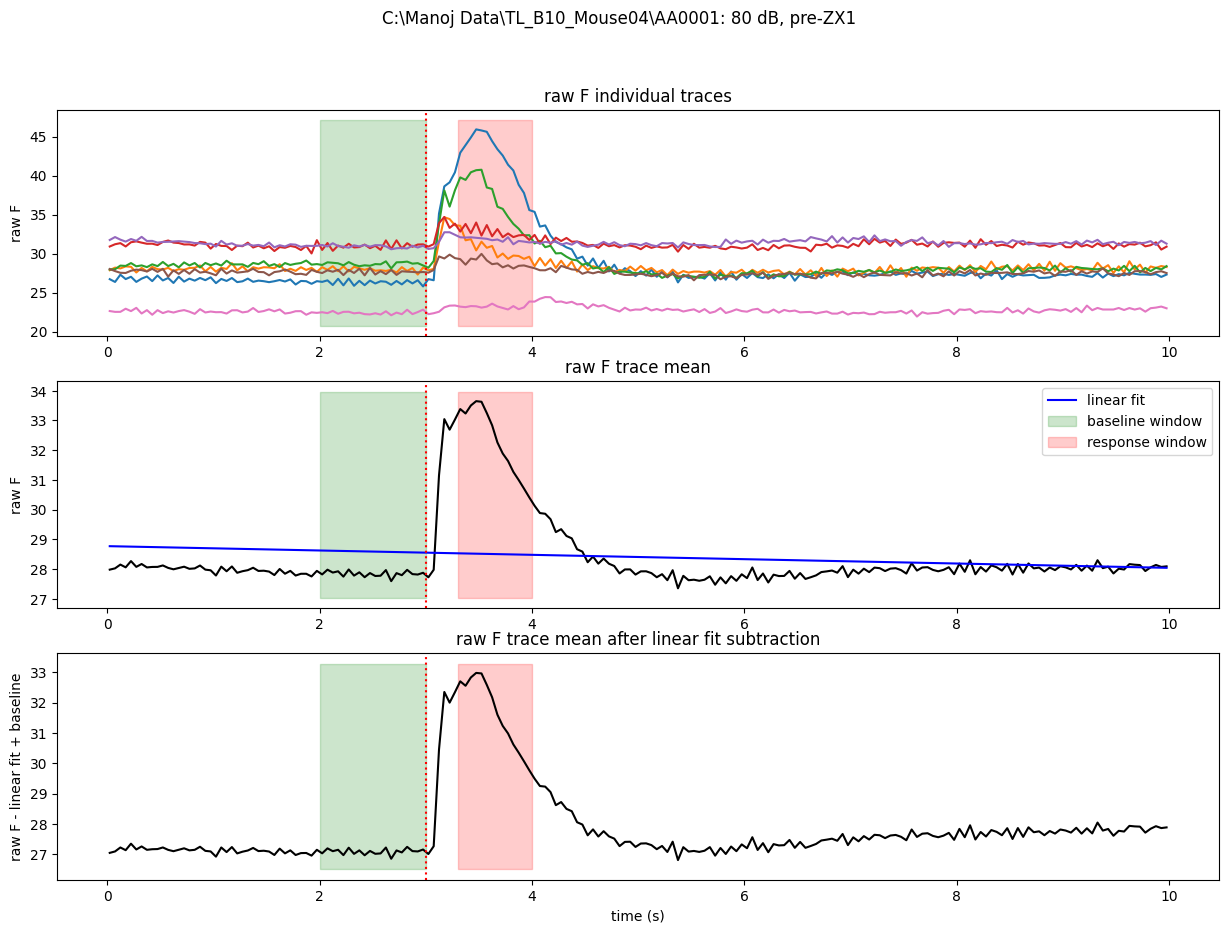

In [ ]:
# preview all traces at 80 dB pre-ZX1
# re-check whether baseline and response time windows are appropriate

import lib.signalProcess as signalProcess
import lib.imgProcess as imgProcess
import matplotlib.pyplot as plt
import os

# import or use newly-generated ROI
# roi_mask = dmask['mask']
roi_mask = dmask_pre['mask']
# roi_mask = joblib.load(os.path.join(df_drop['dir'].iloc[0], 'response_mask.joblib'))

qcams = df_drop[(df_drop['treatment'] == 'preZX1') & (df_drop['dB'] == dB_plot)]['qcam'].tolist()
imgs = imgProcess.qcams2roiTrace(qcams)[2]
t = signalProcess.getTimeVec(imgs.shape[-1])
F_linFilt, slope, intercept = signalProcess.subtractLinFit(t, imgs[:, roi_mask==1, :].mean(axis=(0,1)), t_base = t_base)

fig,ax = plt.subplots(3, 1, figsize=(15,10))

ax[0].plot(t, imgs[:, roi_mask==1, :].mean(axis=1).T)
ax[0].set_ylabel('raw F')
ax[0].set_title("raw F individual traces")

ax[1].plot(t, imgs[:, roi_mask==1, :].mean(axis=(0,1)), 'k-')
ax[1].plot(t, t*slope+intercept, 'b-', label='linear fit')
ax[1].set_title('raw F trace mean')
ax[1].set_ylabel('raw F')

ax[2].plot(t, F_linFilt, 'k-')
ax[2].set_title('raw F trace mean after linear fit subtraction')
ax[2].set_ylabel('raw F - linear fit + baseline')
ax[2].set_xlabel('time (s)')

for axn in ax:
    # set stimulus start point
    axn.axvline(x=t_base[1], color='r', linestyle=':')
    # get the y-axis limits
    ymin, ymax = axn.get_ylim()
    # show baseline and response time window
    axn.fill_betweenx((ymin, ymax), t_base[0], t_base[1], color='g', alpha=0.2, label='baseline window')
    axn.fill_betweenx((ymin, ymax), t_resp[0], t_resp[1], color='r', alpha=0.2, label='response window')

ax[1].legend()

fig.suptitle(f"{df_drop['dir'].iloc[0]}: {dB_plot} dB, pre-ZX1")
plt.show()

In [ ]:
# add ROI mask, time vector, raw F, f0, dF, and dFF for each trace into metadata dataframe
# only consider fluorescence response within ROI
# negative outliers marked by `False` in column `valid`

# Set cutoff frequency for low-pass filter
cutoff_freq=2

import lib.signalProcess as signalProcess

# The function grabs 'response_mask.joblib' file in the experiment folder ('dir') as ROI masks.
# The function grabs 'STIMULUS_START_*_sec*' file in the experiment folder ('dir') to adjust time windows based on when stimuli start.
df_drop = signalProcess.updateTable_signal(df_drop, qcam2img, t_base=t_base, t_resp=t_resp, cutoff_freq=cutoff_freq)
df_drop

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX,ROImask,...,f0_ROI_linFilt_butterFilt,dF_ROI_raw,dF_ROI_raw_peak,dF_ROI_linFilt_butterFilt,dF_ROI_linFilt_butterFilt_peak,dFF_ROI_raw,dFF_ROI_raw_peak,dFF_ROI_linFilt_butterFilt,dFF_ROI_linFilt_butterFilt_peak,valid
0,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_30dB_10000msTotal_Fs250kHz,30.0,preZX1,200,2023-10-11 16:11:23,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,28.241339,"[0.2448750000000004, -0.2501250000000006, 0.17...",0.162375,"[0.18390219626862603, 0.04741203530419469, -0....",0.014121,"[0.008663503168657502, -0.008849244431078956, ...",0.005745,"[0.006511808620208728, 0.0016788168192647447, ...",0.000500,True
1,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_35dB_10000msTotal_Fs250kHz,35.0,preZX1,200,2023-10-11 16:11:46,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,27.851914,"[0.4547500000000042, 0.7397500000000043, 0.679...",0.439750,"[0.3421600960968476, 0.4379978847530488, 0.514...",0.131841,"[0.016181690403964177, 0.02632304667692679, 0....",0.015648,"[0.012284976074637305, 0.01572595283995341, 0....",0.004734,True
2,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,preZX1,200,2023-10-11 16:12:06,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,28.633223,"[0.15337500000000048, 0.010875000000002188, 0....",0.555875,"[0.1478646256874221, 0.07056542924963338, 0.00...",0.256530,"[0.005371378040825992, 0.0003808556557065639, ...",0.019467,"[0.005164093012029276, 0.0024644598962378856, ...",0.008959,True
3,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_75dB_10000msTotal_Fs250kHz,75.0,preZX1,200,2023-10-11 16:12:26,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,27.069614,"[-0.04262500000000102, 0.6323749999999997, -0....",19.294875,"[-1.2069533594115711, -1.1867335153275107, -1....",19.688193,"[-0.001495869907571945, 0.0221923925583762, -0...",0.677129,"[-0.04458701706547326, -0.04384005983949003, -...",0.727317,True
4,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_40dB_10000msTotal_Fs250kHz,40.0,preZX1,200,2023-10-11 16:12:46,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,24.314570,"[0.46875, 0.5437499999999993, 0.65124999999999...",14.903750,"[0.10661295730654174, 0.17084574797874197, 0.2...",15.164288,"[0.01798647417142309, 0.020864310038850756, 0....",0.571874,"[0.004384735537606802, 0.007026476345248514, 0...",0.623671,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_75dB_10000msTotal_Fs250kHz,75.0,postZX1,200,2023-10-11 18:04:17,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,46.073128,"[0.29112500000000807, -0.2938749999999928, 0.4...",0.786125,"[0.1474168859959235, 0.036410935832144276, -0....",0.410806,"[0.006333433950360631, -0.006393260290810246, ...",0.017102,"[0.003199628372246916, 0.0007902857434650484, ...",0.008916,True
124,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,postZX1,200,2023-10-11 18:04:37,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,44.409812,"[0.6864999999999952, 0.09399999999999409, 0.64...",0.601500,"[0.6393188920675072, 0.5976583534239523, 0.558...",

In [53]:
# show traces that should be excluded:
df_drop[~df_drop.valid]

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX,ROImask,...,f0_ROI_linFilt_butterFilt,dF_ROI_raw,dF_ROI_raw_peak,dF_ROI_linFilt_butterFilt,dF_ROI_linFilt_butterFilt_peak,dFF_ROI_raw,dFF_ROI_raw_peak,dFF_ROI_linFilt_butterFilt,dFF_ROI_linFilt_butterFilt_peak,valid
26,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,preZX1,200,2023-10-11 16:20:06,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,28.508394,"[-1.4832499999999982, -1.5182499999999983, -1....",-1.070750,"[-3.86112462761049, -3.3969026236936166, -2.70...",-0.266921,"[-0.048498769751416156, -0.04964318703865673, ...",-0.035011,"[-0.1354381682831766, -0.11915447274078302, -0...",-0.009363,False
62,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_75dB_10000msTotal_Fs250kHz,75.0,preZX1,200,2023-10-11 16:32:06,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,26.454014,"[6.981874999999999, 6.871874999999999, 7.40437...",-1.735625,"[6.060174808639516, 6.191420786673589, 6.29736...",-1.396723,"[0.2535578909140431, 0.24956306602809994, 0.26...",-0.063032,"[0.2290833723810029, 0.23404466016706238, 0.23...",-0.052798,False
95,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_30dB_10000msTotal_Fs250kHz,30.0,postZX1,200,2023-10-11 17:54:57,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,51.595868,"[-0.8364999999999938, -0.9014999999999915, 0.0...",-0.906500,"[-1.1939085375669478, -0.9909907277839665, -0....",-0.868049,"[-0.016373387617686662, -0.017645677151637177,...",-0.017744,"[-0.02313961541020894, -0.019206784769908045, ...",-0.016824,False
121,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_45dB_10000msTotal_Fs250kHz,45.0,postZX1,200,2023-10-11 18:03:37,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,45.286505,"[0.2674999999999983, 0.27999999999999403, 1.06...",-0.110000,"[0.19917474256612167, 0.2611829924815723, 0.30...",-0.308856,"[0.005919451206018993, 0.006196061075459039, 0...",-0.002434,"[0.004398103600852708, 0.0057673470286190645, ...",-0.006820,False
127,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_40dB_10000msTotal_Fs250kHz,40.0,postZX1,200,2023-10-11 18:05:37,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,45.147501,"[2.8262500000000017, 3.03125, 2.72124999999999...",-0.898750,"[2.402065512469001, 2.5695263181779, 2.6792446...",-0.910493,"[0.062339739171193065, 0.06686150707215528, 0....",-0.019824,"[0.053204838207622306, 0.056914031411392195, 0...",-0.020167,False


In [54]:
# exclude negative outliers
df_drop_drop = df_drop[df_drop.valid]
df_drop_drop

,qcam,dir,xsg,pulse,dB,treatment,nFrames,timestamp_init,dim_YX,ROImask,...,f0_ROI_linFilt_butterFilt,dF_ROI_raw,dF_ROI_raw_peak,dF_ROI_linFilt_butterFilt,dF_ROI_linFilt_butterFilt_peak,dFF_ROI_raw,dFF_ROI_raw_peak,dFF_ROI_linFilt_butterFilt,dFF_ROI_linFilt_butterFilt_peak,valid
0,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_30dB_10000msTotal_Fs250kHz,30.0,preZX1,200,2023-10-11 16:11:23,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,28.241339,"[0.2448750000000004, -0.2501250000000006, 0.17...",0.162375,"[0.18390219626862603, 0.04741203530419469, -0....",0.014121,"[0.008663503168657502, -0.008849244431078956, ...",0.005745,"[0.006511808620208728, 0.0016788168192647447, ...",0.000500,True
1,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_35dB_10000msTotal_Fs250kHz,35.0,preZX1,200,2023-10-11 16:11:46,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,27.851914,"[0.4547500000000042, 0.7397500000000043, 0.679...",0.439750,"[0.3421600960968476, 0.4379978847530488, 0.514...",0.131841,"[0.016181690403964177, 0.02632304667692679, 0....",0.015648,"[0.012284976074637305, 0.01572595283995341, 0....",0.004734,True
2,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,preZX1,200,2023-10-11 16:12:06,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,28.633223,"[0.15337500000000048, 0.010875000000002188, 0....",0.555875,"[0.1478646256874221, 0.07056542924963338, 0.00...",0.256530,"[0.005371378040825992, 0.0003808556557065639, ...",0.019467,"[0.005164093012029276, 0.0024644598962378856, ...",0.008959,True
3,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_75dB_10000msTotal_Fs250kHz,75.0,preZX1,200,2023-10-11 16:12:26,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,27.069614,"[-0.04262500000000102, 0.6323749999999997, -0....",19.294875,"[-1.2069533594115711, -1.1867335153275107, -1....",19.688193,"[-0.001495869907571945, 0.0221923925583762, -0...",0.677129,"[-0.04458701706547326, -0.04384005983949003, -...",0.727317,True
4,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\Control\AA...,6-64kHz_40dB_10000msTotal_Fs250kHz,40.0,preZX1,200,2023-10-11 16:12:46,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,24.314570,"[0.46875, 0.5437499999999993, 0.65124999999999...",14.903750,"[0.10661295730654174, 0.17084574797874197, 0.2...",15.164288,"[0.01798647417142309, 0.020864310038850756, 0....",0.571874,"[0.004384735537606802, 0.007026476345248514, 0...",0.623671,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_50dB_10000msTotal_Fs250kHz,50.0,postZX1,200,2023-10-11 18:03:57,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,44.991738,"[1.0700000000000003, 0.09499999999999886, 0.83...",0.887500,"[1.0930227081233355, 0.7345201218703394, 0.411...",0.447414,"[0.023736897565304203, 0.0021074815595363288, ...",0.019688,"[0.024293853608406177, 0.016325666594598467, 0...",0.009944,True
123,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,C:\Manoj Data\TL_B10_Mouse04\AA0001,C:\Manoj Data\TL_B10_Mouse04\AA0001\AA0001AZXA...,6-64kHz_75dB_10000msTotal_Fs250kHz,75.0,postZX1,200,2023-10-11 18:04:17,"(130, 174)","[[False, False, False, False, False, False, Fa...",...,46.073128,"[0.29112500000000807, -0.2938749999999928, 0.4...",0.786125,"[0.1474168859959235, 0.036410935832144276, -0....",

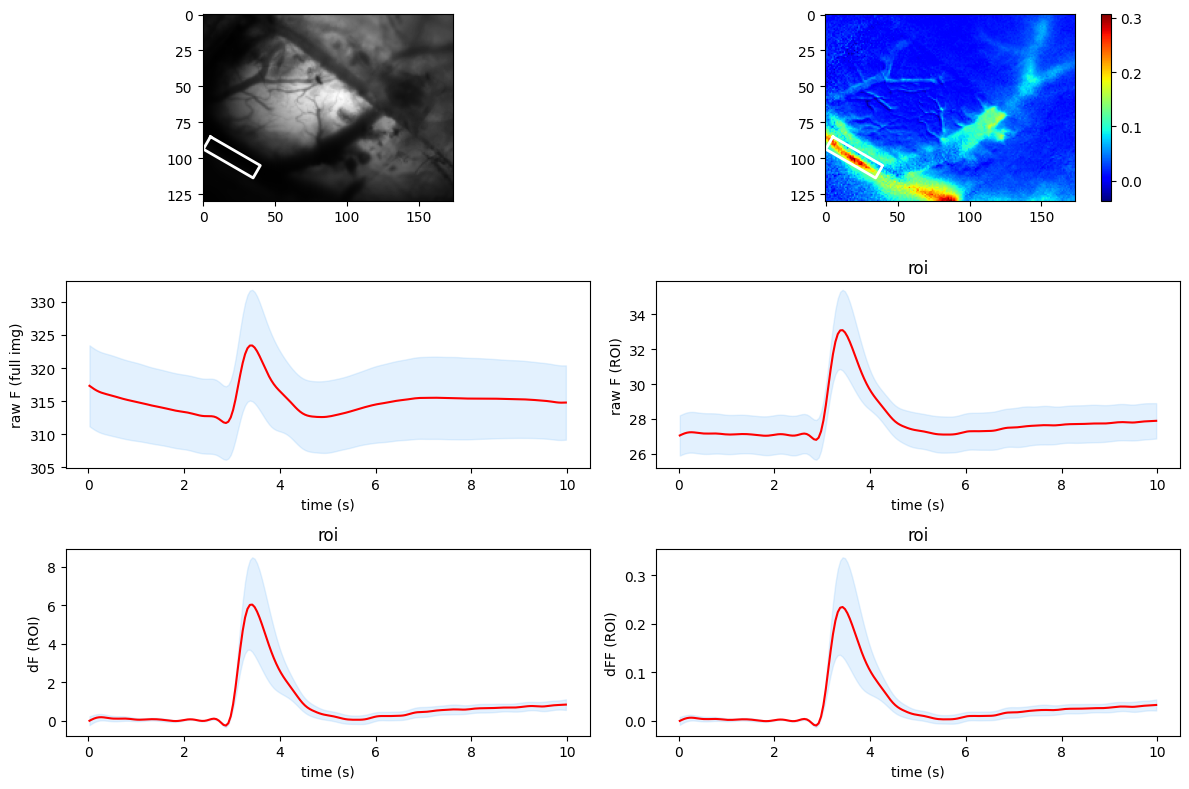

(7, 200)

In [ ]:
# plot averaged raw F, dF, and dFF traces within ROI 

# # recalculate averaged fluorescence response with updated dataframe where outliers are removed
# 80 dB, pre-ZX1
qcams = df_drop_drop[(df_drop_drop['dB']==dB_plot) & (df_drop_drop['treatment']=='preZX1')]['qcam'].tolist()

# 80 dB, post-ZX1
# qcams = df_drop_drop[(df_drop_drop['dir']==expDir) & (df_drop_drop['dB']==dB_plot) & (df_drop_drop['treatment']=='postZX1')]['qcam'].tolist()

# all sound intensities, pre-ZX1
# qcams = df_drop_drop[(df_drop_drop['dir']==expDir) & (df_drop_drop['treatment']=='preZX1')]['qcam'].tolist()

_, _, imgs, spatialDFF = imgProcess.qcams2roiTrace(qcams, t_baseline=t_base, t_temporalAvg=t_resp)


# plot averaged traces with error bars after linear fit subtraction and low-pass filter
# roiTrace = imgProcess.mask2trace(imgs=imgs, spatialDFF=spatialDFF, **dmask, t_base=t_base, cutoff_freq=cutoff_freq)
roiTrace = imgProcess.mask2trace(imgs=imgs, spatialDFF=spatialDFF, **dmask_pre, t_base=t_base, cutoff_freq=cutoff_freq)

# plot averaged raw traces without any processing
# roiTrace = imgProcess.mask2trace(imgs=imgs, spatialDFF=spatialDFF, **dmask, t_base=t_base, subLinFit=False, butterFilt=False)

# plot averaged traces without error bars after linear fit subtraction and low-pass filter
# roiTrace = imgProcess.mask2trace(imgs=imgs, spatialDFF=spatialDFF, **dmask, t_base=t_base, errBar=False, cutoff_freq=cutoff_freq)

roiTrace.shape

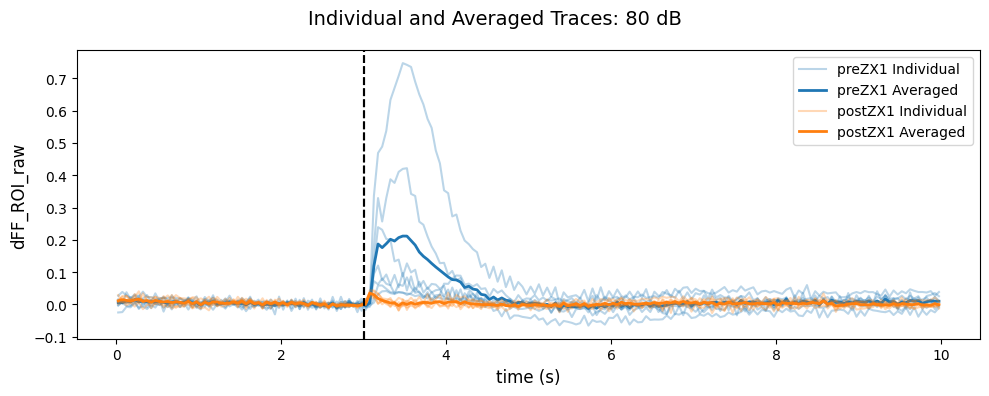

In [56]:
# Plot individual and averaged traces at a given sound level pre- and post-ZX1

import lib.plotting as plotting

# Plot dFF raw traces at 80 dB (pre- and post-ZX1) in one plot
plotting.plot_traces(df_drop_drop, dB_plot=80, resp_col='dFF_ROI_raw', sepPlot=False)

# Plot dFF raw traces at 80 dB with pre- and post-ZX1 in separate subplots
# plotting.plot_traces(df_drop_drop, dB_plot=80, resp_col='dFF_ROI_raw', sepPlot=True)

# Same for dFF processed traces after subtracting linear fit and applying low-pass filter
# plotting.plot_traces(df_drop_drop, dB_plot=80, resp_col='dFF_ROI_linFilt_butterFilt', sepPlot=False)

# Same for dF traces
# plotting.plot_traces(df_drop_drop, dB_plot=80, resp_col='dF_ROI_raw', sepPlot=False)

In [57]:
# plot dFF (or dF) response traces across different sound intensties pre- or post-ZX1

import lib.plotting as plotting

# dFF response
plotting.plotDF_levelByTreatment(df_drop_drop, qcam2img, dFResp=False, sepPlot=True, roi_mask=roi_mask, t_base=t_base)

# dF response
# plotting.plotDF_levelByTreatment(df_drop_drop, qcam2img, dFResp=True, sepPlot=True, roi_mask=roi_mask, t_base=t_base)

# dFF response, show pre- and post-ZX1 traces in one plot
# plotting.plotDF_levelByTreatment(df_drop_drop, qcam2img, dFResp=False, sepPlot=False, roi_mask=roi_mask, t_base=t_base)

(7, 200)
(5, 200)


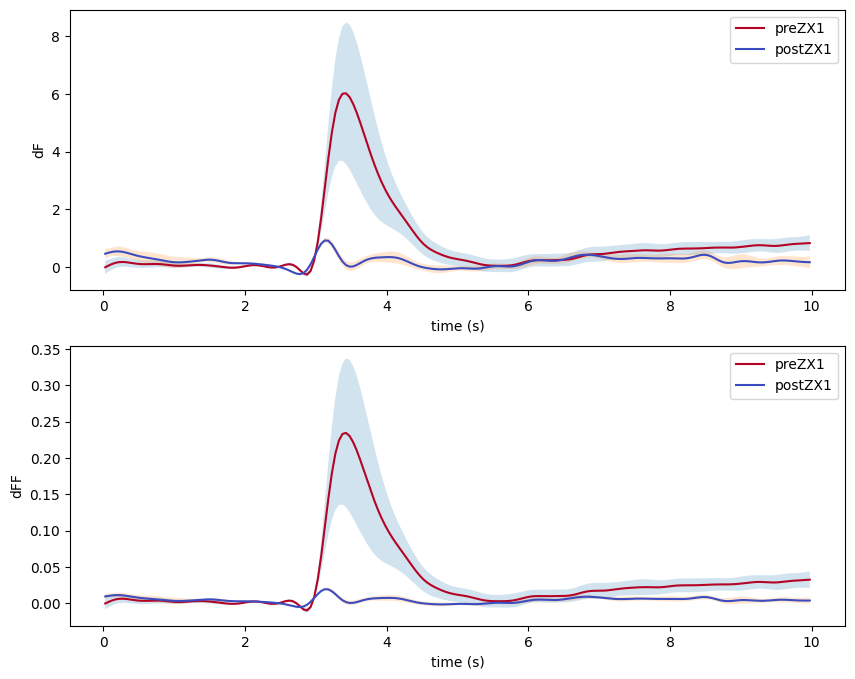

In [58]:
# plot dF and dFF response traces pre- and post-ZX1

import numpy as np
import matplotlib.pyplot as plt
import lib.signalProcess as signalProcess
import matplotlib.cm as cm

n_q = 2
colors = np.flipud(cm.coolwarm(np.linspace(0, 1, n_q)))

t = signalProcess.getTimeVec(imgs.shape[-1])
fig, ax = plt.subplots(2, 1, figsize=(10,8))

# all sound intensities
# for i,(a,b) in enumerate(df_drop_drop[df_drop_drop['dir']==expDir].groupby('treatment', sort=False)):
# 80 dB
for i,(a,b) in enumerate(df_drop_drop[df_drop_drop['dB']==dB_plot].groupby('treatment', sort=False)):
    print(np.array(b['F_ROI_raw'].tolist()).shape)

    # raw data
    # dF = np.array(b['dF_ROI_raw'].tolist())
    # dFF = np.array(b['dFF_ROI_raw'].tolist())

    # processed data
    dF = np.array(b['dF_ROI_linFilt_butterFilt'].tolist())
    dFF = np.array(b['dFF_ROI_linFilt_butterFilt'].tolist())
    
    uDF, uDFpsem, uDFmsem = signalProcess.meanPlusMinusSem(dF)
    uDFF, uDFFpsem, uDFFmsem = signalProcess.meanPlusMinusSem(dFF)

    ax[0].set_xlabel('time (s)')
    ax[0].set_ylabel('dF')
    ax[1].set_xlabel('time (s)')
    ax[1].set_ylabel('dFF')
    ax[0].plot(t, uDF, '-', color=colors[i], label=a)
    ax[0].fill_between(t, uDFmsem, uDFpsem, alpha=0.2)
    ax[1].plot(t, uDFF, '-', color=colors[i], label=a)
    ax[1].fill_between(t, uDFFmsem, uDFFpsem, alpha=0.2)

ax[0].legend()
ax[1].legend()

In [59]:
# plot peak response amplitudes across sound intensities

import plotly.express as px

# # histogram showing averaged peak dFF across intensities between pre- and post-ZX1
# fig = px.histogram(df_drop_drop[df_drop_drop['dir']==expDir], x="dB", y="dFF_ROI_linFilt_butterFilt_peak",
#                    color="treatment", barmode='group', histfunc='avg', height=400)

# # violin plot showing distribution of peak dFF across intensities between pre- and post-ZX1
# dFF response
fig = px.violin(df_drop_drop, y="dFF_ROI_linFilt_butterFilt_peak", x="dB", color="treatment", box=True, points='all')

# dF response
# fig = px.violin(df_drop_drop[df_drop_drop['dir']==expDir], y="dF_ROI_linFilt_butterFilt_peak", x="dB", color="treatment", box=True, points='all')

fig.show()

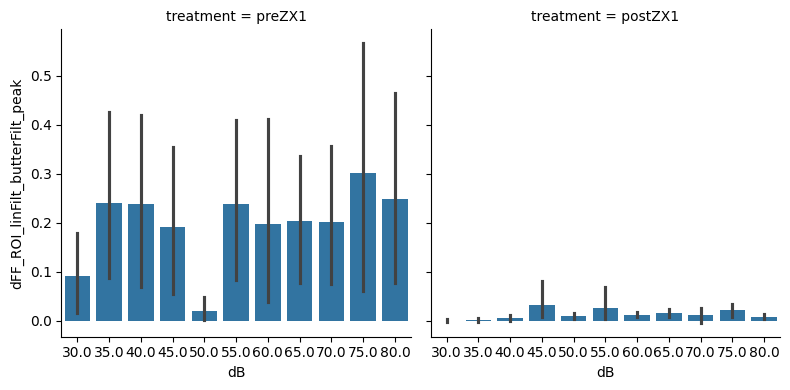

In [60]:
# plot barplots across sound intensities, pre- and post-ZX1, showing error bars

import seaborn as sns

# y_max = df_drop_drop[df_drop_drop['dir']==expDir]["dFF_ROI_linFilt_butterFilt_peak"].max()
# for a,b in df_drop_drop[df_drop_drop['dir']==expDir].groupby('treatment', sort=False):
#     plt.figure()
#     sns.barplot(b, x="dB", y="dFF_ROI_linFilt_butterFilt_peak")
#     plt.ylim(0, y_max)
#     plt.title(a)

# plot the two barplots side by side with same Y-axis scale
g = sns.FacetGrid(df_drop_drop, col="treatment", sharey=True, height=4)
g.map_dataframe(sns.barplot, x="dB", y="dFF_ROI_linFilt_butterFilt_peak")

# same for dF response
# g.map_dataframe(sns.barplot, x="dB", y="dF_ROI_linFilt_butterFilt_peak")